**Chapter 2 – End-to-End Machine Learning Project**

*This notebook contains all the sample code and solutions to the exercises in chapter 2.*

In [1]:
println("Welcome to Machine Learning!")

Welcome to Machine Learning!


This project requires Julia 1.12 or above:

In [2]:
@assert VERSION >= v"1.12"

It also requires MLJ ≥ 0.22.0:

In [5]:
import MLJ
@assert pkgversion(MLJ) >= v"0.22.0"

# Get the Data

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

## Download the Data

In [6]:
import Downloads: download
using CodecZlib: GzipDecompressorStream
using Tar
using DataFrames, CSV

function load_housing_data()
    if !isdir("data")
        mkdir("data")
    end

    data_path = "data/housing/housing.csv"
    tgz_path = "data/housing.tgz"

    if !isfile(data_path)
        if !isfile(tgz_path)
            url = "https://github.com/ageron/data/raw/main/housing.tgz"
            download(url, tgz_path)
        end

        rm("tmp"; force=true, recursive=true)
        open(GzipDecompressorStream, tgz_path) do io
            Tar.extract(io, "tmp")
        end
        mv("tmp/housing", "data/housing")
        rm("tmp"; force=true, recursive=true)
    end

    CSV.read(data_path, DataFrame)
end

housing_full = load_housing_data();

## Take a Quick Look at the Data Structure

In [7]:
first(housing_full, 5)

Row,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64,Float64,String15
1,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
2,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
4,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
5,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
describe(housing_full)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,Type
1,longitude,-119.57,-124.35,-118.49,-114.31,0,Float64
2,latitude,35.6319,32.54,34.26,41.95,0,Float64
3,housing_median_age,28.6395,1.0,29.0,52.0,0,Float64
4,total_rooms,2635.76,2.0,2127.0,39320.0,0,Float64
5,total_bedrooms,537.871,1.0,435.0,6445.0,207,"Union{Missing, Float64}"
6,population,1425.48,3.0,1166.0,35682.0,0,Float64
7,households,499.54,1.0,409.0,6082.0,0,Float64
8,median_income,3.87067,0.4999,3.5348,15.0001,0,Float64
9,median_house_value,2.06856e5,14999.0,179700.0,500001.0,0,Float64


In [9]:
# Helper function to simulate value_counts in Pandas
using StatsBase

function value_counts(data::AbstractVector; order::Bool=true,
                      ascending::Bool=false, dropna::Bool=true)
    data = dropna ? collect(skipmissing(data)) : data
    kvs = collect(countmap(data))

    if order
        kvs = sort(kvs; by=x -> x[2], rev=!ascending)        
    end

    return DataFrame(value=map(t -> t[1], kvs), count=map(t -> t[2], kvs))    
end

value_counts (generic function with 1 method)

In [10]:
value_counts(housing_full.ocean_proximity)

Row,value,count
,String15,Int64
1,<1H OCEAN,9136
2,INLAND,6551
3,NEAR OCEAN,2658
4,NEAR BAY,2290
5,ISLAND,5


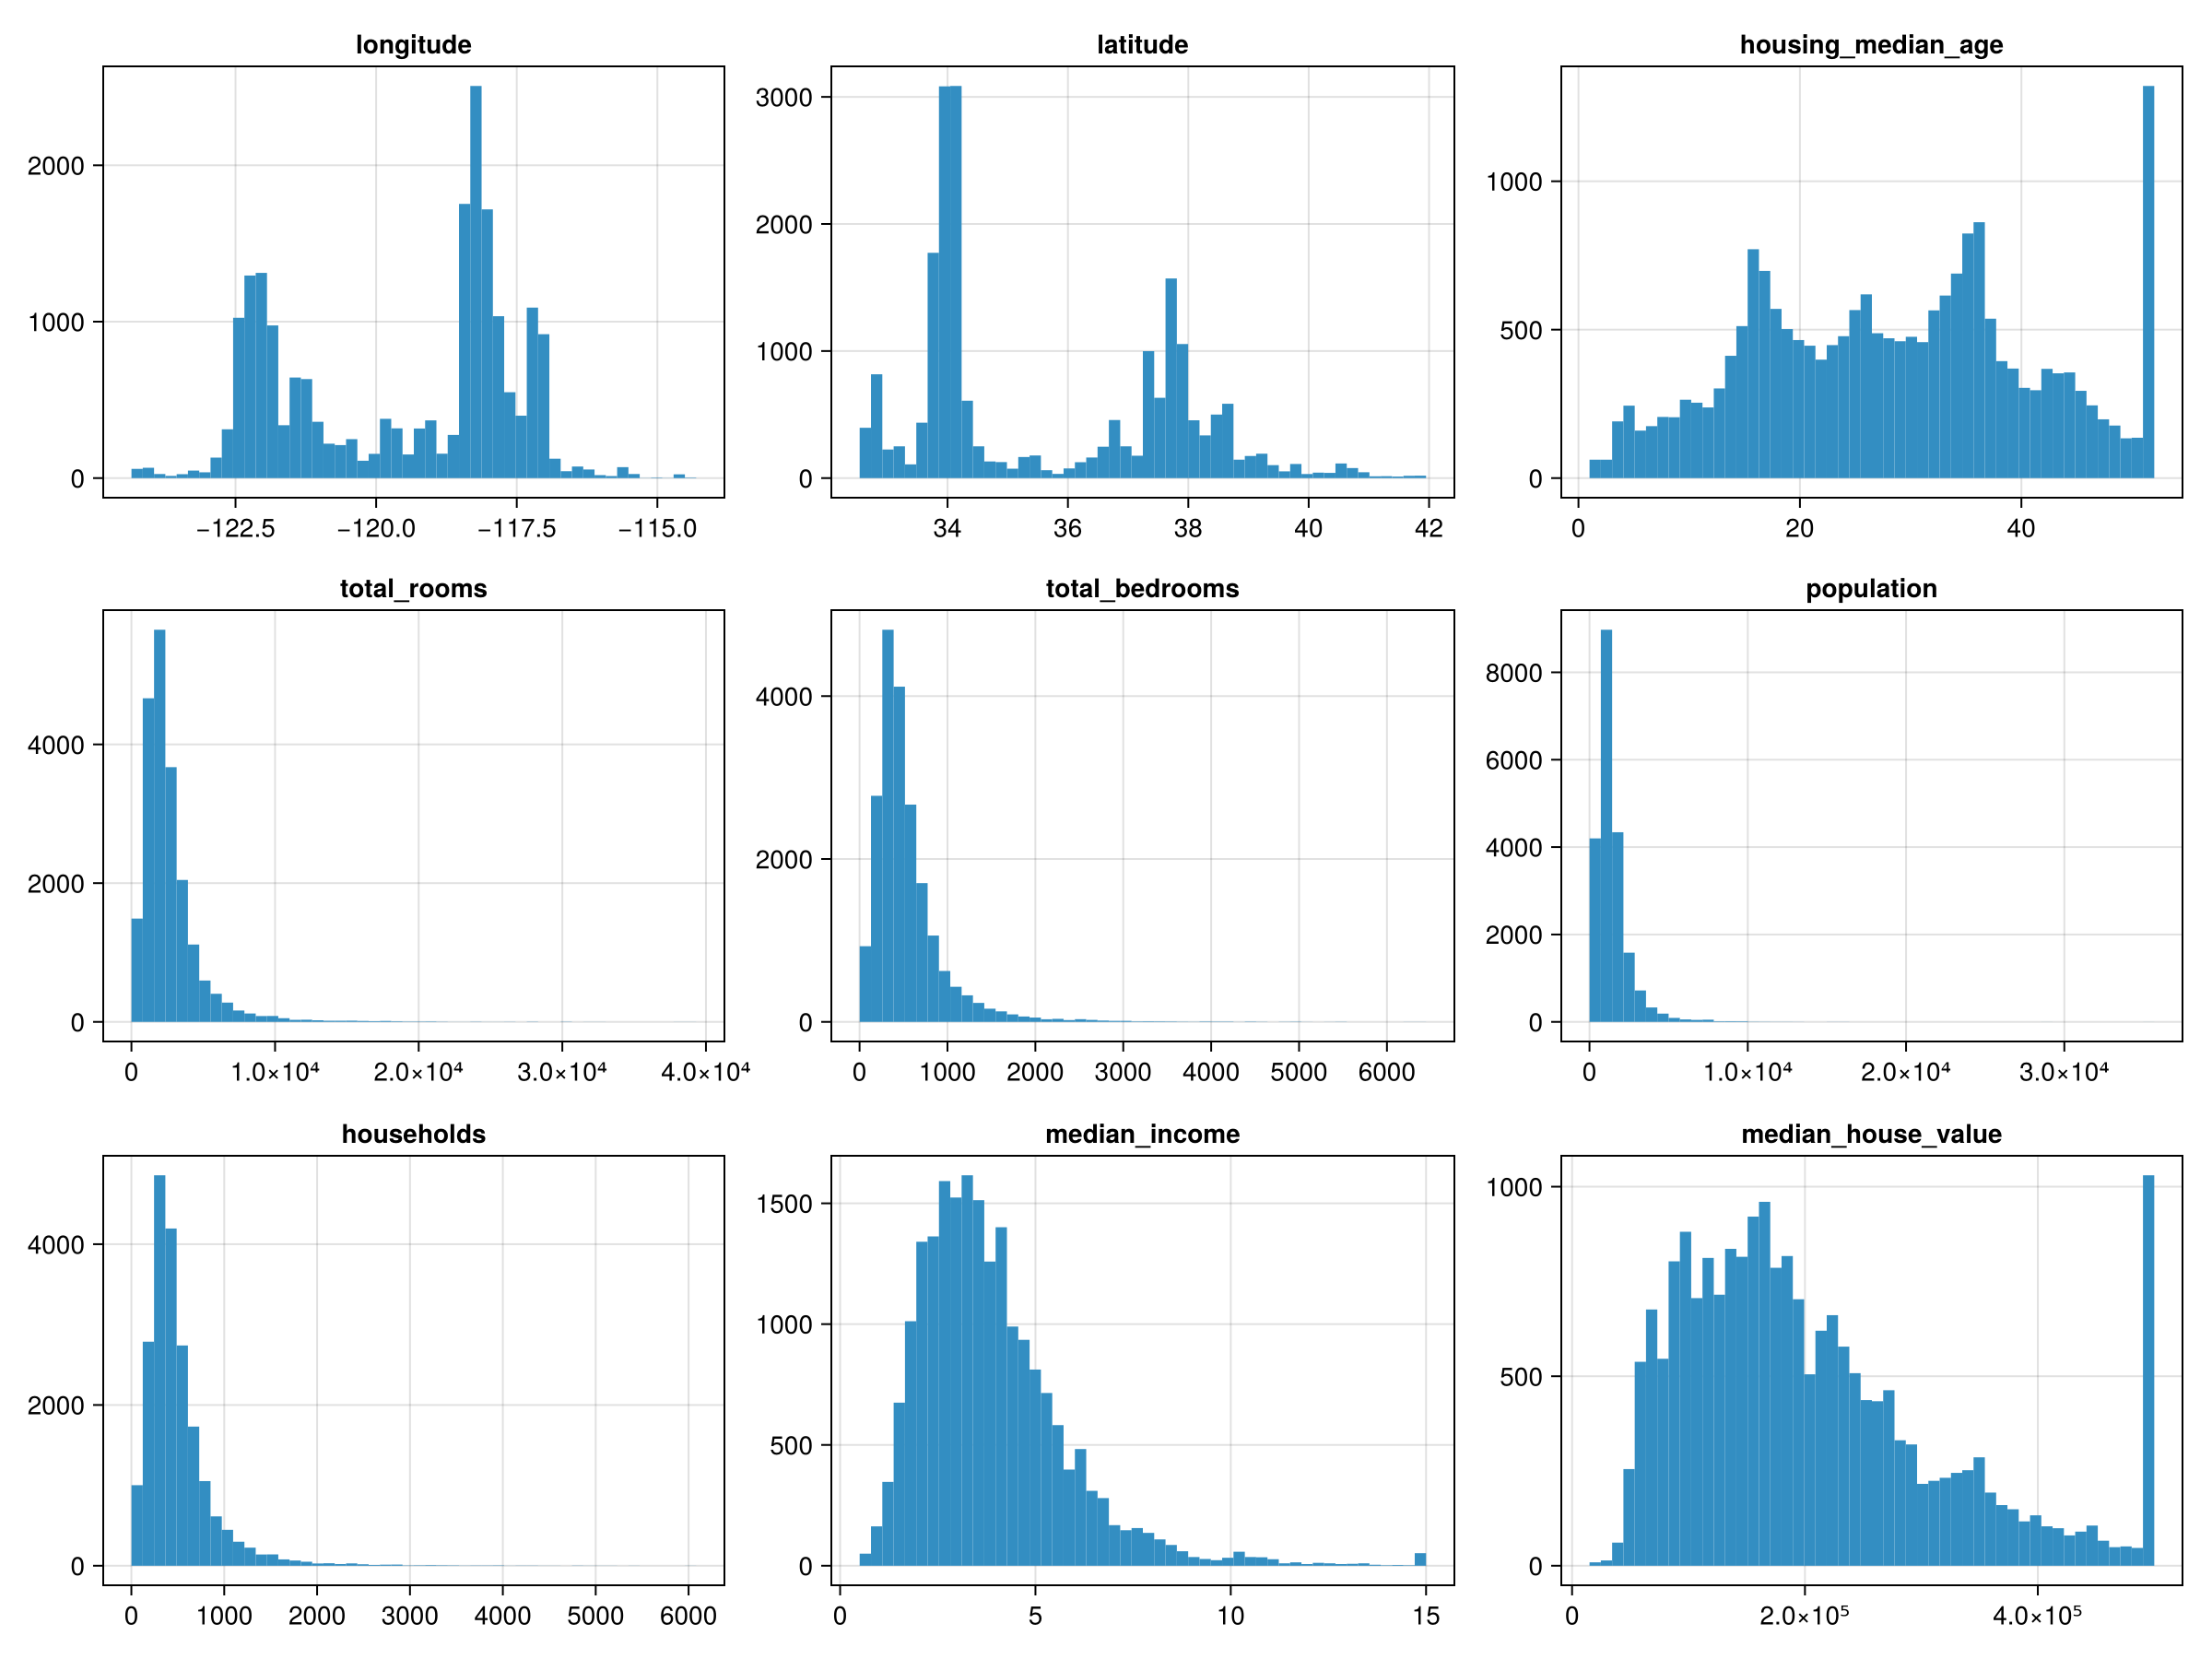

In [11]:
using CairoMakie

number_cols = names(housing_full, Union{Missing, Real})
n_cols = length(number_cols)
n_rows = n_cols ÷ 3
cols_per_row = min(n_cols, 3)

fig = Figure(size=(400 * cols_per_row, 300 * n_rows))

for (i, col) in enumerate(number_cols)
    ax = Axis(fig[div(i-1, cols_per_row) + 1, mod1(i, cols_per_row)], title=col)
    data = housing_full[!, col]
    hist!(
        ax, 
        any(ismissing, data) ? collect(skipmissing(data)) : data,
        bins = 50
    )
end
fig

## Create a Test Set

In [12]:
using Random

function shuffle_and_split_data(data::AbstractDataFrame, test_ratio::AbstractFloat, rng::AbstractRNG = Random.default_rng())
    rows = nrow(data)
    shuffled_indices = randperm(rng, rows)
    test_set_size = Int(floor(rows * test_ratio))
    test_indices = shuffled_indices[1:test_set_size]
    train_indices = shuffled_indices[(test_set_size+1):end]
    data[train_indices, :], data[test_indices, :]
end

shuffle_and_split_data (generic function with 2 methods)

To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [13]:
Random.seed!(42)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2)
nrow(train_set)

16512

In [14]:
nrow(test_set)

4128

Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

In [15]:
using CRC32c

function is_id_in_test_set(identifier::Real, test_ratio::AbstractFloat)
    crc32c(reinterpret(UInt8, [identifier])) < test_ratio * 2^32
end

function split_data_with_id_hash(data::AbstractDataFrame, test_ratio::AbstractFloat, id_column::Symbol)
    ids = data[!, id_column]
    in_test_set = map(id -> is_id_in_test_set(id, test_ratio), ids)
    data[.!in_test_set, :], data[in_test_set, :]
end

split_data_with_id_hash (generic function with 1 method)

In [16]:
housing_with_id = hcat(housing_full, DataFrame(index=1:nrow(housing_full))) # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, :index);

In [17]:
housing_with_id[!, :index] = housing_full.longitude .* 1000 .+ housing_full.latitude
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, :index);

In [18]:
train_set, test_set = MLJ.partition(housing_full, 0.8; rng=42);

In [19]:
count(ismissing, test_set.total_bedrooms)

43

To find the probability that a random sample of 1,000 people contains less than 49% female or more than 54% female when the population's female ratio is 51.6%, we use the [binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution). The `cdf()` gives us the probability that the number of females will be equal or less than the given value.

In [20]:
using Distributions

sample_size = 1000
ratio_female = 0.516
proba_too_small = cdf(Binomial(sample_size, ratio_female), 490 - 1)
proba_too_large = 1 - cdf(Binomial(sample_size, ratio_female), 540)
println(proba_too_small + proba_too_large)


0.1072742266745599


If you prefer simulations over maths, here's how you could get roughly the same result:

In [21]:
Random.seed!(42)

samples = sum(rand(Float64, (100_000, sample_size)) .< ratio_female; dims = 2)
mean((samples .< 490) .|| (samples .> 540))

0.10668

In [22]:
using CategoricalArrays
housing_full.income_cat = cut(housing_full.median_income, [0., 1.5, 3., 4.5, 6., Inf];
                              labels = [1, 2, 3, 4, 5]);

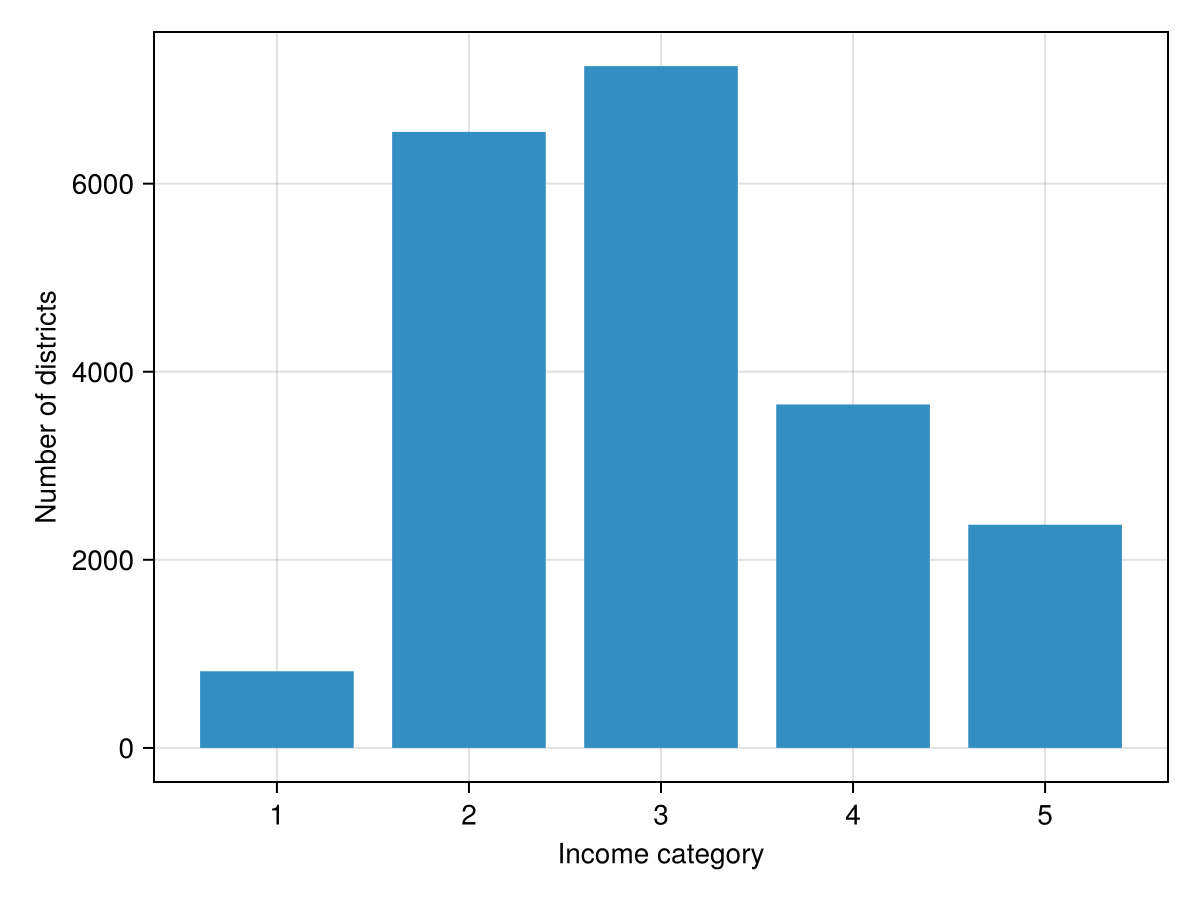

In [23]:
cat_counts = value_counts(housing_full.income_cat)

fig = Figure()
ax = Axis(fig[1, 1]; xlabel = "Income category", ylabel = "Number of districts")
barplot!(ax, unwrap.(cat_counts.value), cat_counts.count)

fig

In [ ]:
strat_train_set, strat_test_set = MLJ.partition(housing_full, 0.8; rng=42, stratify=housing_full.income_cat);

In [28]:
train_cat_counts = value_counts(strat_train_set.income_cat)
train_cat_counts.prop = train_cat_counts.count / nrow(strat_train_set)
train_cat_counts

Row,value,count,prop
,Cat…,Int64,Float64
1,3,5800,0.35126
2,2,5240,0.317345
3,4,2922,0.176962
4,5,1898,0.114947
5,1,652,0.0394864


In [60]:
# extra code – computes the data for Figure 2–10

function income_cat_proportions(data::AbstractDataFrame, colname::AbstractString)
    df = value_counts(data.income_cat)
    DataFrame(:income_cat=>df.value, Symbol(colname)=>df.count / nrow(data))
end

train_set, test_set = MLJ.partition(housing_full, 0.8; rng=42)

compare_props = sort(
    outerjoin(
        income_cat_proportions(housing_full, "Overall %"),
        income_cat_proportions(strat_test_set, "Stratified %"),
        income_cat_proportions(test_set, "Random %");
        on=:income_cat
    ),
    :income_cat
)

compare_props[!, "Strat. Error %"] = compare_props[!, "Stratified %"] ./ compare_props[!, "Overall %"] .- 1
compare_props[!, "Rand. Error %"] = compare_props[!, "Random %"] ./ compare_props[!, "Overall %"] .- 1


compare_props[!, names(compare_props, Union{Real, Missing})] = round.(
    compare_props[!, names(compare_props, Union{Real, Missing})] .* 100;
    digits=2
)

compare_props


Row,income_cat,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
,Cat…,Float64,Float64,Float64,Float64,Float64
1,1,3.95,3.95,3.63,0.0,-7.98
2,2,31.73,31.73,32.0,0.0,0.84
3,3,35.13,35.13,35.17,0.0,0.14
4,4,17.69,17.68,17.54,-0.05,-0.88
5,5,11.5,11.51,11.65,0.08,1.35


In [61]:
for set in (strat_train_set, strat_test_set)
    select!(set, Not(:income_cat))
end

# Discover and Visualize the Data to Gain Insights

In [65]:
housing = copy(strat_train_set, copycols=true);

## Visualizing Geographical Data

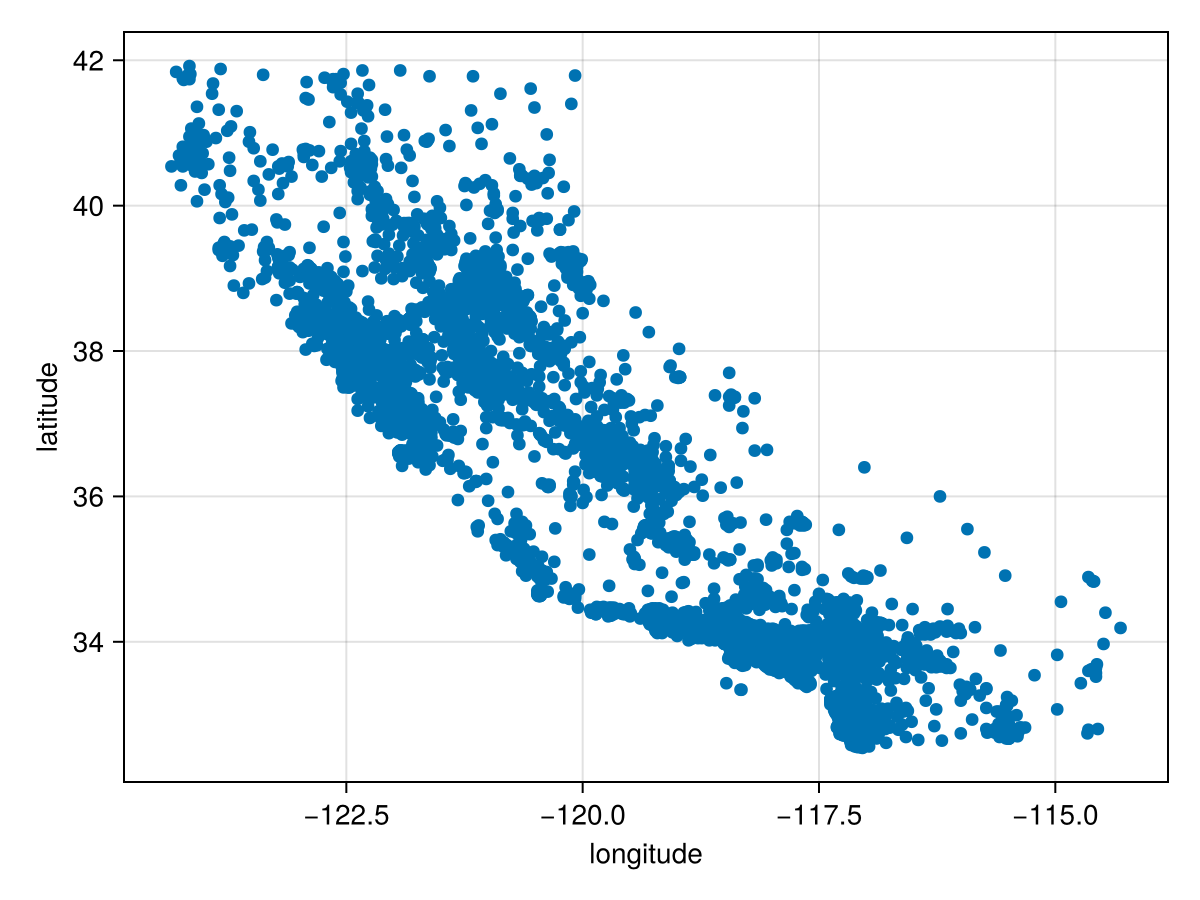

In [69]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel="longitude", ylabel="latitude")
scatter!(ax, housing.longitude, housing.latitude)
fig

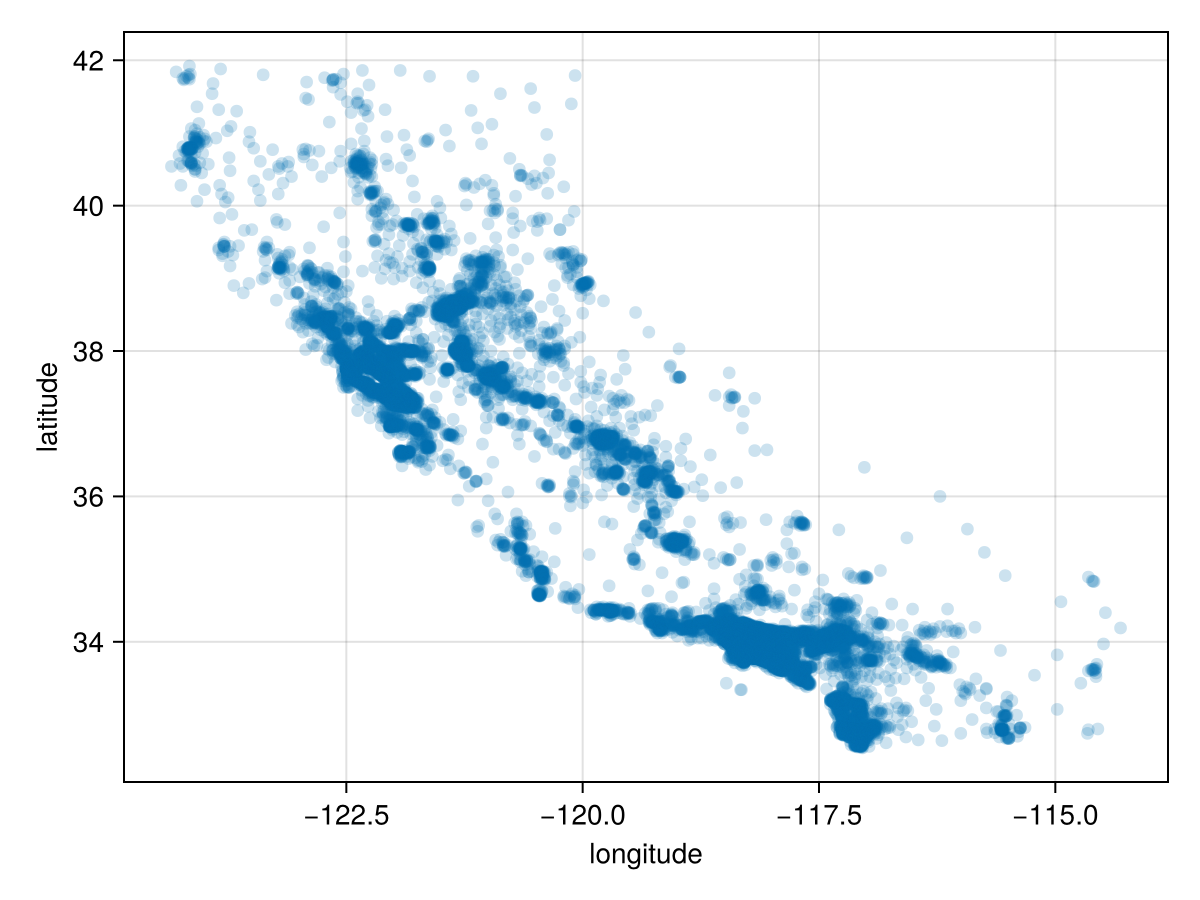

In [70]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel="longitude", ylabel="latitude")
scatter!(ax, housing.longitude, housing.latitude; alpha=0.2)
fig

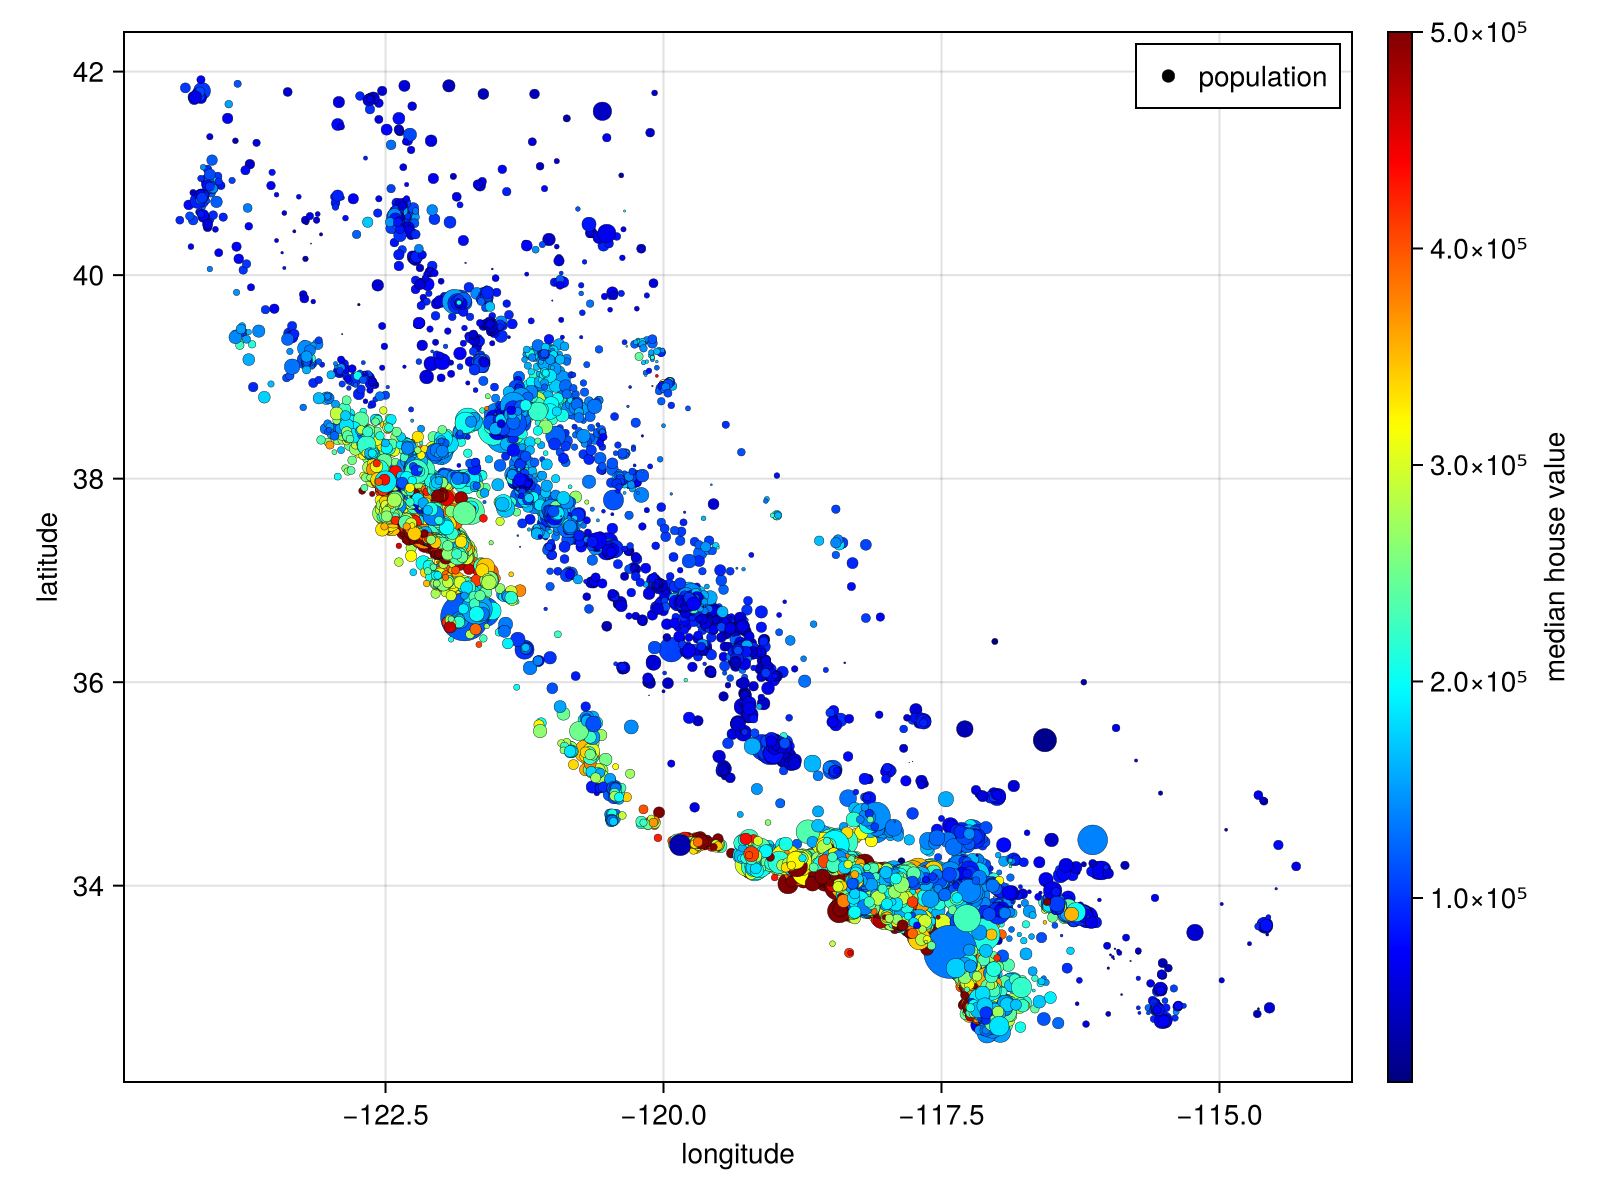

In [95]:
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1]; xlabel="longitude", ylabel="latitude")
sc = scatter!(
    ax,
    housing.longitude,
    housing.latitude,
    markersize = 2 .* sqrt.(housing.population ./ 100),
    color = housing.median_house_value,
    colormap = :jet, 
    strokewidth = 0.2,
    strokecolor = :black,
    transparency = true,
    label = "population"
)
axislegend(position = :rt)

Colorbar(fig[1, 2], sc; label = "median house value")

fig